🧠 Accuracy analysis Jupyter notebook

📦 Install required packages

In [1]:
!pip install nltk sentence-transformers torch PyMuPDF
!pip install pandas
!pip install matplotlib
!pip install -U kaleido
!pip install plotly

📚 Import libraries

In [1]:
import nltk
import torch
import fitz  # PyMuPDF
import pandas as pd
from pathlib import Path
from sentence_transformers import SentenceTransformer, util
from nltk.tokenize import sent_tokenize
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np
import plotly.graph_objects as go
import plotly.io as pio

nltk.download('punkt')
nltk.download('punkt_tab')


/home/bogdan/Desktop/Execo-rep-pkg/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[nltk_data] Downloading package punkt to /home/bogdan/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /home/bogdan/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

🏷️ Define accuracy codebook

In [3]:
codebook = [
    {"code": "Correctness", "description": "The extent to which the generated code is functionally correct and produces the expected outputs."},
    {"code": "Security", "description": "The likelihood of the model introducing vulnerabilities, such as insecure coding practices, which may lead to exploitability."},
    {"code": "Error Propagation", "description": "The degree to which errors accumulate when the model generates longer code sequences, potentially leading to cascading failures."},
    {"code": "Benchmark Performance", "description": "The effectiveness of the model as measured by established metrics, such as pass@k, BLEU, and CodeBLEU, which provide quantitative assessments of accuracy."},
    {"code": "Human-Perceived Accuracy", "description": "The extent to which users trust the correctness of the generated code, even when it is syntactically valid but may contain logical flaws."}
]

code_descriptions = [code['description'] for code in codebook]

📄 Load and extract text from all PDFs in the folder

In [4]:
def extract_text_from_pdf(pdf_path):
    text = ""
    with fitz.open(pdf_path) as doc:
        for page in doc:
            text += page.get_text() + ""
    return text

# Set path to your folder of PDFs
pdf_folder = Path("./Papers/")  # Put your PDFs here
pdf_files = list(pdf_folder.glob("*.pdf"))
print(f"Found {len(pdf_files)} PDF files.")

Found 70 PDF files.


🤖 Load model

In [5]:
model = SentenceTransformer('all-mpnet-base-v2')

🧠 Process each PDF

In [6]:
results = []
threshold = 0.5

code_embeddings = model.encode(code_descriptions, convert_to_tensor=True)

for pdf_path in pdf_files:
    text = extract_text_from_pdf(pdf_path)
    segments = sent_tokenize(text)
    text_embeddings = model.encode(segments, convert_to_tensor=True)
    
    for i, segment in enumerate(segments):
        sim_scores = util.cos_sim(text_embeddings[i], code_embeddings)[0]
        for score, code_idx in zip(sim_scores, range(len(codebook))):
            if score >= threshold:
                results.append({
                    "File": pdf_path.name,
                    "Text Segment": segment,
                    "Code": codebook[code_idx]['code'],
                    "Score": float(score)
                })

print(f"✅ Done processing {len(pdf_files)} files. Total coded segments: {len(results)}")

✅ Done processing 70 files. Total coded segments: 1238


💾 Export to CSV

In [7]:
df = pd.DataFrame(results)
df.to_csv("./CSVs/coded_output_from_pdfs_accuracy.csv", index=False, encoding='utf-8')
df.head()

,File,Text Segment,Code,Score
0,000538538.pdf,Two\nindependent reviewers evaluated the outpu...,Benchmark Performance,0.521734
1,000538538.pdf,Results: Signiﬁcant\ndifferences were observed...,Benchmark Performance,0.524048
2,000538538.pdf,To\nevaluate the consistency between the revie...,Benchmark Performance,0.516610
3,000538538.pdf,Completeness\nThe depth and thoroughness of th...,Correctness,0.553431
4,000538538.pdf,Readability Assessment\nThe understandability ...,Benchmark Performance,0.529747


💾 Aggregate frequency and document count per code

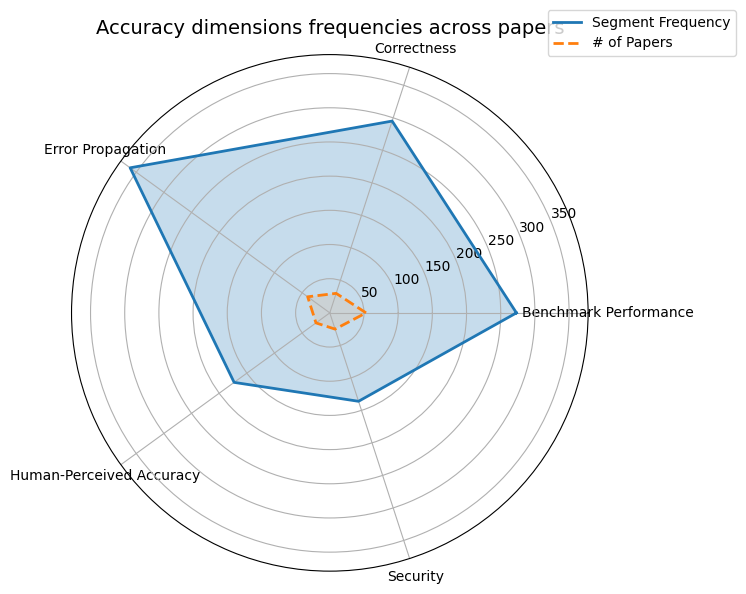

In [8]:
code_stats = df.groupby("Code").agg({
    "Text Segment": "count",
    "File": pd.Series.nunique
}).rename(columns={
    "Text Segment": "Frequency",
    "File": "Documents"
}).reset_index()

labels = code_stats["Code"].tolist()
freq = code_stats["Frequency"].tolist()
docs = code_stats["Documents"].tolist()
# Radar setup
angles = np.linspace(0, 2 * np.pi, len(labels), endpoint=False).tolist()
freq += freq[:1]
docs += docs[:1]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 6), subplot_kw=dict(polar=True))
ax.plot(angles, freq, label="Segment Frequency", linewidth=2)
ax.fill(angles, freq, alpha=0.25)

ax.plot(angles, docs, label="# of Papers", linestyle='dashed', linewidth=2)
ax.fill(angles, docs, alpha=0.1)

ax.set_thetagrids(np.degrees(angles[:-1]), labels)
plt.title("Accuracy dimensions frequencies across papers", fontsize=14)
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.tight_layout()

# Show plot
plt.show()

Radar plot with the curated CSV file through ChatGPT

In [2]:
# Load data
data = pd.read_csv("./CSVs/curated_codes_accuracy.csv")
label_counts = data['Code'].value_counts()

# Create bar plot (occurrences of codes)
fig = go.Figure(data=go.Bar(
    x=label_counts.index,
    y=label_counts.values,
    marker_color='red'
))

fig.update_layout(
    xaxis_title='Codes',
    yaxis_title='Number of Occurrences',
    showlegend=False
)

# Export as PDF
pio.write_image(fig, "./Figures/bar_plot_codes_occurances_accuracy.pdf", format="pdf")


# Export exact numbers as CSV
label_counts.reset_index().rename(columns={'index': 'Code', 'Code': 'Occurrences'}).to_csv(
    "./CSVs/bar_plot_codes_occurrences_accuracy.csv",
    index=False
)

In [3]:
# Load data
data = pd.read_csv("./CSVs/curated_codes_accuracy.csv")

# Count the number of unique papers per code
papers_per_code = data.groupby('Code')['File'].nunique().sort_values(ascending=False)

# Create bar plot (number of papers per code)
fig = go.Figure(data=go.Bar(
    x=papers_per_code.index,
    y=papers_per_code.values,
    marker_color='red'
))

fig.update_layout(
    xaxis_title='Code',
    yaxis_title='Number of Papers',
    showlegend=False
)

# Export as PDF
pio.write_image(fig, "./Figures/bar_plot_papers_per_code_accuracy.pdf", format="pdf")


# Export exact numbers as CSV
papers_per_code.reset_index().rename(columns={'File': 'Number_of_Papers'}).to_csv(
    "./CSVs/bar_plot_papers_per_code_accuracy.csv",
    index=False
)